# Predictive maintenance workshop: Part 2 - Decision making 🔍 📊

#### ✅ How to use this notebook

1. To save your own progress: Go to **File → Save a copy in Drive** (recommended)
2. The cell below will automatically **download all required data** from the course repository.  
3. You can run cells one by one using the play button on the top left of the cell or `Shift + Enter`.

**⚠️ Note: All work done here is temporary unless you save your own copy. Each time you reopen the notebook, Colab starts a new session.**

In [ ]:
# Execute this cell. Do not modify it! It makes the notebook executable with Google Colab.
import sys

if 'google.colab' in sys.modules:
    # Clone repository
    !git clone https://github.com/bbrisch/summer_school_prog_dm.git
    # Move into repo
    %cd summer_school_prog_dm
    # Print folder content
    !ls
else:
    print("Not running in Google Colab environment.")

# Install packages
!pip install -r requirements.txt

Not running in Google Colab environment.


In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
from numpy import ndarray
import matplotlib.pyplot as plt
%matplotlib inline
from typing import Any

from src_decision_making.decision_config import config
from src_decision_making.replacement_agent import ReplacementAgent
import src_decision_making.visualization as vis

plt.rcParams.update(
    {
        "font.family": "serif",
        "axes.labelsize": 22,
        "legend.fontsize": 15,
        "lines.linewidth": 2.5,
        "font.size": 18,
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{bm} \usepackage{amsmath}",
        "figure.figsize": (10, 6),
    }
)

## Assignment

After you have trained a prognostic model, now your task is to define a policy takes achieves a good maintenance performance. The performance measure is the maintenance cost rate, i.e., 

$$\frac{E[C]}{E[T]}$$

In the below cells, there are some example benchmark policies that you should be able to beat. Your policy takes as an input at each time step a) the prognostic information, b) the current time, c) some policy-specific parameters that are passed as a list. The custom parameters in c) should be fixed a-priori and should not contain information about the time to failure of the components. Or, in simple terms, do not cheat.

Once you have defined and evaluated your policy as well as the benchmarks, you can visually compare their performances. Feel free to define additional diagnostics that might be useful to you.

### Benchmark policies

In [ ]:
def do_nothing(prog: ndarray, time: int, pol_args: list) -> ndarray:
    """
    Does nothing every time step -> corrective maintenance policy.

    Args:
        prog (N, D): prognostic information
        time: current time/age of the component
        pol_args: list of policy-specific arguments

    Returns:
        acts (N,): array of 0/1 for each component, where 0==DN & 1==PR
    """
    return np.zeros(prog.shape[0])
    
def prob_thres(prog: ndarray, time: int, pol_args: list) -> ndarray:
    """
    Simple probability threshold based policy.

    Args:
        prog (N, D): prognostic information at a certain timestep
        time: current time/age of the component
        pol_args: list of policy-specific arguments

    Returns:
        acts (N,): array of 0/1 for each component, where 0==DN & 1==PR
    """
    a = np.zeros(len(prog)) 

    ub = pol_args[0]
    pf_thres = pol_args[1]
    
    supp = np.arange(prog.shape[1])

    # first find x of support, then interpolate
    cdf = np.cumsum(prog, axis=1) # (N, D)
    pf_preds = np.array(
        [np.interp(x=ub, xp=supp, fp=cdf[k,:]) for k in range(cdf.shape[0])]
    ).squeeze() # (N,)

    a[pf_preds > pf_thres] = 1
    return a

def age_pol(prog: ndarray, time: int, pol_args: list) -> ndarray:
    """
    Age-based replacement policy: components either fail or are replaced at the
    floored replacement age.

    Args:
        prog (N, D): prognostic information
        time: current time/age of the component
        pol_args: list of policy-specific arguments

    Returns:
        acts (N,): array of 0/1 for each component, where 0==DN & 1==PR
    """
    t_rep = pol_args[0]
    Delta_T = pol_args[1]
    t_rep_floor = (t_rep // Delta_T) * Delta_T

    if time == t_rep_floor:
        a = np.ones(prog.shape[0])
    else:
        a = np.zeros(prog.shape[0]) 
    return a

In [3]:
# create ReplacementAgent object
A = ReplacementAgent(cf=config)

In [4]:
# evaluate the benchmark policies
c_opt, t_opt, cr_opt, var_cr_opt = A.opt_pol(tfs=A.trainval_tfs)

c_dn, t_dn, cr_dn, var_cr_dn = A.eval_pol(pol=do_nothing, tfs=A.trainval_tfs, prog=A.trainval_prog)

prob_pol_args = [config["Delta_T"], config["c_p"] / config["c_c"]]
c_prob, t_prob, cr_prob, var_cr_prob = A.eval_pol(pol=prob_thres, tfs=A.trainval_tfs, prog=A.trainval_prog, pol_args=prob_pol_args)

age_pol_args = [A.trainval_tfs.mean(), config["Delta_T"]]
c_age, t_age, cr_age, var_cr_age = A.eval_pol(pol=age_pol, tfs=A.trainval_tfs, prog=A.trainval_prog, pol_args=age_pol_args)

In [5]:
def mypol(prog: list, time: int, pol_args: Any) -> ndarray:
    """
    General template for the custom policy.

    Args:
        prog (N, D): list of prognostic information for a batch of N components
        time: the current time passed
        pol_args: list of policy-specific arguments
    
    Returns:
        acts (N,): array of 0/1 for each component, where 0==DN & 1==PR
    """
    acts = np.zeros(len(prog))

    ## TODO: populate now entries of action vector based on chosen heuristic

    return acts

In [6]:
# TODO: define here the parameters of your policy and evaluate it
my_pol_args = [A.trainval_tfs.mean(), config["Delta_T"]]
c_my, t_my, cr_my, var_cr_my = A.eval_pol(pol=mypol, tfs=A.trainval_tfs, prog=A.trainval_prog, pol_args=age_pol_args)

### Visualize results

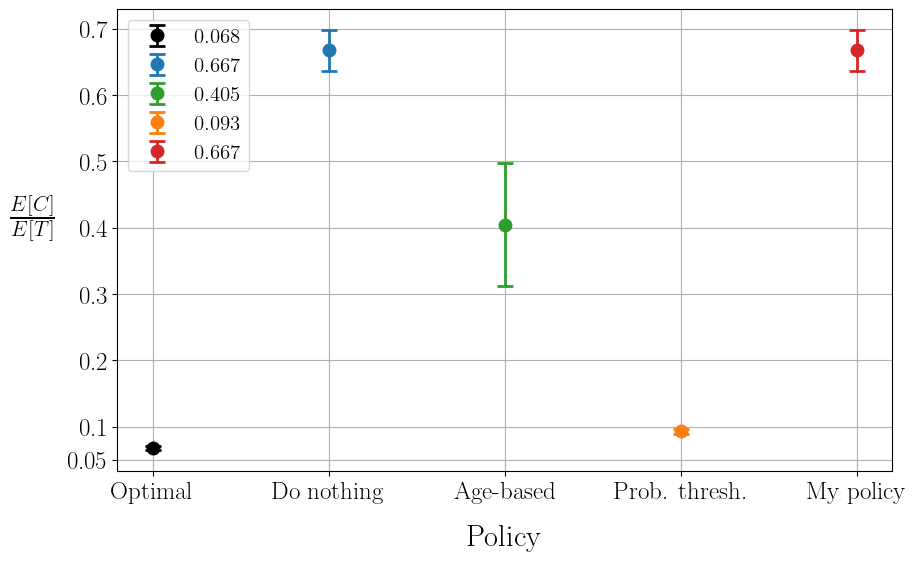

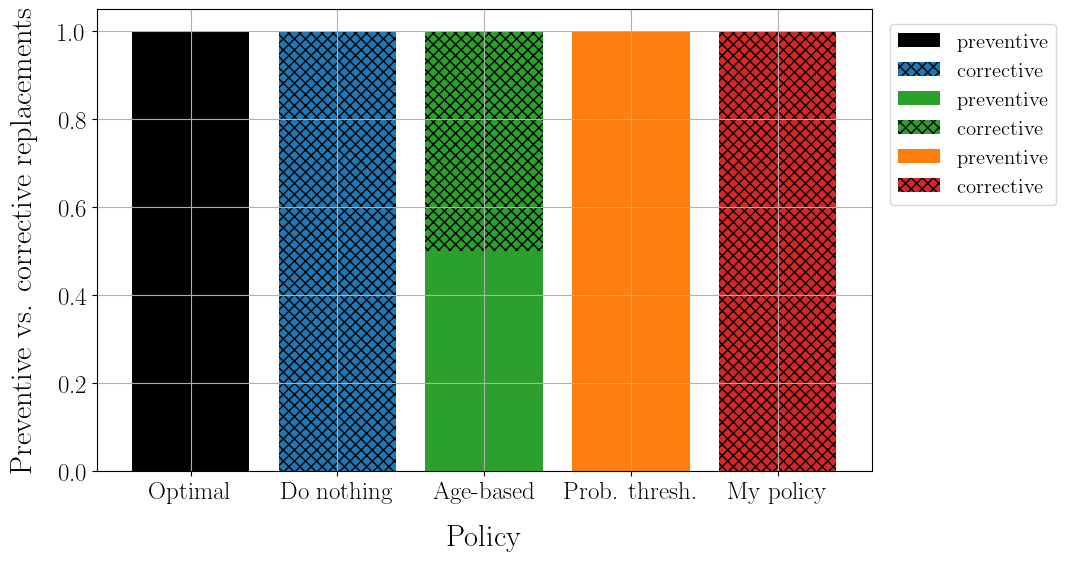

In [32]:
results = {}

if "cr_opt" in globals():
    results["opt_pol"] = (c_opt, t_opt, cr_opt, var_cr_opt)

if "cr_dn" in globals():
    results["do_nothing"] = (c_dn, t_dn, cr_dn, var_cr_dn)

if "cr_age" in globals():
    results["age"] = (c_age, t_age, cr_age, var_cr_age)

if "cr_prob" in globals():
    results["prob_thres"] = (c_prob, t_prob, cr_prob, var_cr_prob)

if "cr_my" in globals():
    results["my_policy"] = (c_my, t_my, cr_my, var_cr_my)

vis.plot_policy_comparison(results=results)
vis.plot_cp_vs_cc(results=results)

## Final testing on test set, do not touch beforehand!

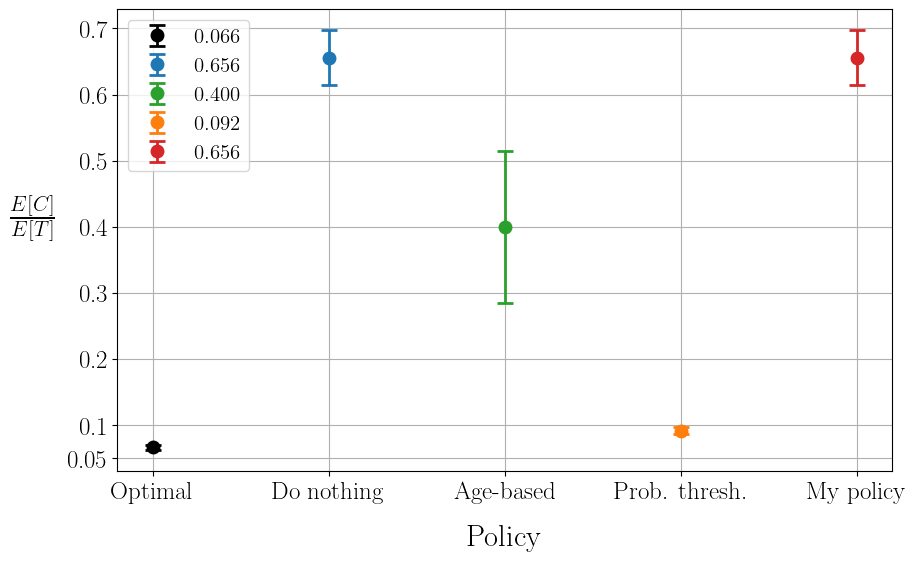

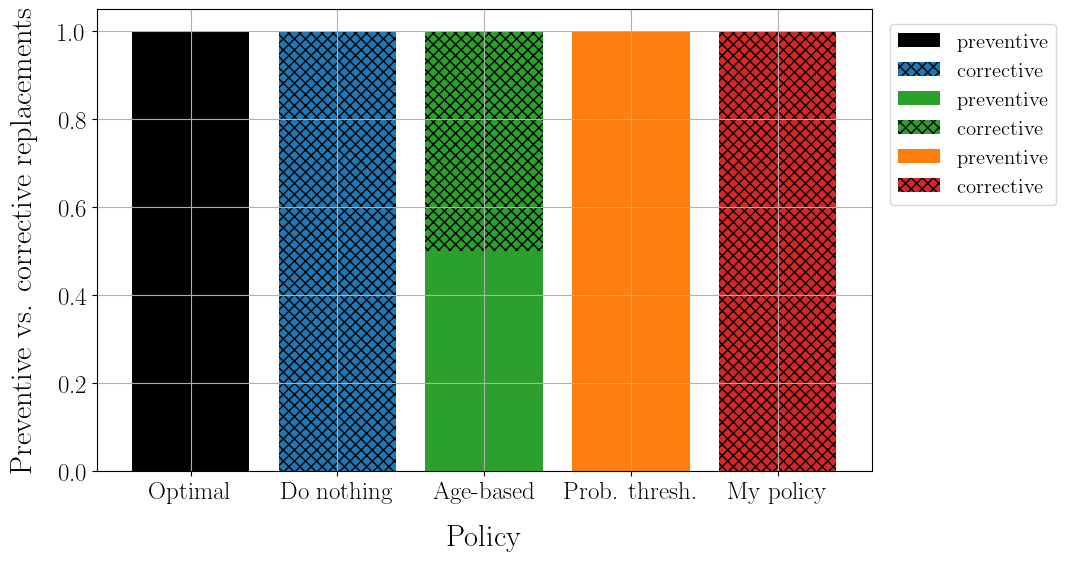

In [33]:
# evaluate the benchmark policies
c_opt_test, t_opt_test, cr_opt_test, var_cr_opt_test = A.opt_pol(tfs=A.test_tfs)

c_dn_test, t_dn_test, cr_dn_test, var_cr_dn_test = A.eval_pol(pol=do_nothing, tfs=A.test_tfs, prog=A.test_prog)

prob_pol_args = [config["Delta_T"], config["c_p"] / config["c_c"]]
c_prob_test, t_prob_test, cr_prob_test, var_cr_prob_test = A.eval_pol(pol=prob_thres, tfs=A.test_tfs, prog=A.test_prog, pol_args=prob_pol_args)

age_pol_args = [A.test_tfs.mean(), config["Delta_T"]]
c_age_test, t_age_test, cr_age_test, var_cr_age_test = A.eval_pol(pol=age_pol, tfs=A.test_tfs, prog=A.test_prog, pol_args=age_pol_args)

c_my_test, t_my_test, cr_my_test, var_cr_my_test = A.eval_pol(pol=mypol, tfs=A.test_tfs, prog=A.test_prog, pol_args=age_pol_args)

test_results = {}

if "cr_opt" in globals():
    test_results["opt_pol"] = (c_opt_test, t_opt_test, cr_opt_test, var_cr_opt_test)

if "cr_dn" in globals():
    test_results["do_nothing"] = (c_dn_test, t_dn_test, cr_dn_test, var_cr_dn_test)

if "cr_age" in globals():
    test_results["age"] = (c_age_test, t_age_test, cr_age_test, var_cr_age_test)

if "cr_prob" in globals():
    test_results["prob_thres"] = (c_prob_test, t_prob_test, cr_prob_test, var_cr_prob_test)

if "cr_my" in globals():
    test_results["my_policy"] = (c_my_test, t_my_test, cr_my_test, var_cr_my_test)

vis.plot_policy_comparison(results=test_results)
vis.plot_cp_vs_cc(results=test_results)